# Insurance Charges - Modelling
**Input:** ../data/model_ready/

This notebook trains, compares, tunes, and evaluates regression models.

### Training the Baseline Model & Making Predictions

**The Objective:**
We will use Scikit-Learn's `LinearRegression` class to act as our baseline model. Because our dataset is relatively small, this algorithm will use an exact mathematical solver (Singular Value Decomposition) to find the perfect Ordinary Least Squares (OLS) weights without needing iterative Gradient Descent.

In [291]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [292]:
X_train = pd.read_csv('../data/model_ready/X_train.csv')
X_test = pd.read_csv('../data/model_ready/X_test.csv')
y_train = pd.read_csv('../data/model_ready/y_train.csv').squeeze()
y_test = pd.read_csv('../data/model_ready/y_test.csv').squeeze()

In [293]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


###  Model Evaluation & Diagnosing Overfitting

**The Objective:**
We must translate our model's mathematical accuracy into real-world business metrics. We will evaluate the model using three key performance indicators:
1. **$R^2$ (R-Squared):** The percentage of the target's variance explained by our features.
2. **MAE (Mean Absolute Error):** The average dollar amount our predictions are off by.
3. **RMSE (Root Mean Squared Error):** The average error, heavily penalized for massive outliers.

**The Methodology:**
To ensure our model actually learned human biology (and didn't just memorize the data), we will calculate these metrics for **both** the Training Set and the Testing Set. A large gap between these scores indicates **Overfitting**.

In [294]:

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
# we have to wrap MSE in numpy's square root function to get RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


print(f"{'Metric':<15} | {'Training Set':<20} | {'Testing Set':<20}")
print(f"{'R-Squared (R²)':<15} | {train_r2:<20.4f} | {test_r2:<20.4f}")
print(f"{'MAE':<15} | ${train_mae:<19,.2f} | ${test_mae:<19,.2f}")
print(f"{'RMSE':<15} | ${train_rmse:<19,.2f} | ${test_rmse:<19,.2f}\n")

# Diagnostic check for Overfitting
gap = train_r2 - test_r2
print(f"Diagnostic: The Train/Test R² Gap is {gap:.4f}")
if gap > 0.08:
    print("Model is memorizing data (Overfitting).")
else:
    print("Gap is healthy. Model is generalizing well")

Metric          | Training Set         | Testing Set         
R-Squared (R²)  | 0.7351               | 0.8046              
MAE             | $0.28                | $0.27               
RMSE            | $0.45                | $0.40               

Diagnostic: The Train/Test R² Gap is -0.0695
Gap is healthy. Model is generalizing well


In [295]:
#the rmse and mae values are very small because we have used log charges, we can use np.exp to convert it into actual charges.

### Coefficient Interpretation

**The Objective:**
Linear Regression allows us to extract the exact mathematical weights assigned to each feature. By examining these coefficients, we can definitively prove which patient attributes drive hospital costs the highest.

*Note: Because our target variable (`charges`) was log-transformed, these coefficients represent the change in the natural log of the cost. Because our continuous variables were Standardized, their coefficients represent the change per standard deviation.*

In [296]:
lr_model.intercept_#this stores the bias(the baseline hospital fee even if there is no age sex or smoking factor)

np.float64(8.493393498603078)

In [297]:
linear_weights = lr_model.coef_#this attribute stores the weights
features = X_train.columns
linear_coefficients_df = pd.DataFrame({
    'Feature': features,
    'Weights': linear_weights
})
linear_coefficients_df

,Feature,Weights
0,age,0.464492
1,is_female,0.078117
2,bmi,0.004836
3,children,0.117271
4,is_smoker,1.451890
5,region_northwest,-0.045990
6,region_southeast,-0.121695
7,region_southwest,-0.103104
8,bmi_category_Normal,0.231686
9,bmi_category_Overweight,0.284918


Text(0, 0.5, 'Frequency')

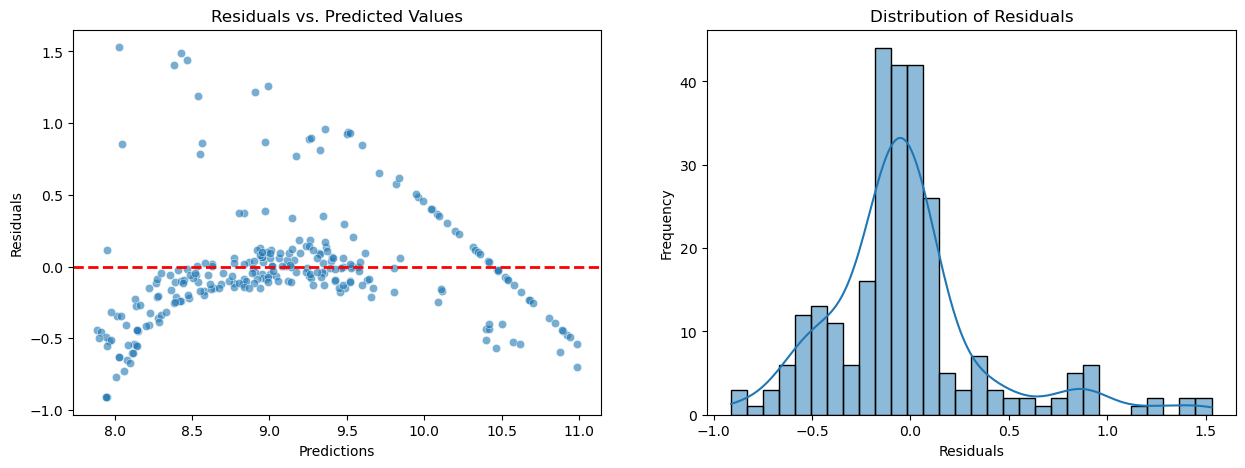

In [298]:
residuals = y_test - y_test_pred
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predictions')
axes[0].set_ylabel('Residuals')

sns.histplot(residuals, kde=True, ax=axes[1], bins=30)

axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')


### Lasso Regression (Feature Selection)

**The Objective:**
Standard Linear Regression uses every single feature we give it, which can lead to overfitting if we have noisy or useless columns (like `region`). We will train a **Lasso Regression (L1 Regularization)** model. 

**The Mechanics:**
Lasso applies a mathematical "tax" (controlled by the hyperparameter `alpha`) to the model's weights. If a feature is not highly predictive, Lasso will ruthlessly shrink its weight to exactly `0.0`, effectively deleting it from the equation. We will compare Lasso's weights to our baseline Linear Regression to see which features get deleted.

In [299]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha = 0.01, random_state = 42)
lasso_model.fit(X_train, y_train)

lasso_weights = lasso_model.coef_

weights_df = pd.DataFrame({
    'Feature': features,
    'Linear Weight': linear_weights,
    'Lasso Weight': lasso_weights
})

weights_df['Linear Weight'] = weights_df['Linear Weight'].round(2)
weights_df['Lasso Weight'] = weights_df['Lasso Weight'].round(4)

display(weights_df)

lasso_test_pred = lasso_model.predict(X_test)
print(f"\nLasso R²: {r2_score(y_test, lasso_test_pred):.4f}")



,Feature,Linear Weight,Lasso Weight
0,age,0.46,0.4603
1,is_female,0.08,0.0319
2,bmi,0.00,0.0353
3,children,0.12,0.1082
4,is_smoker,1.45,1.3788
5,region_northwest,-0.05,0.0000
6,region_southeast,-0.12,-0.0096
7,region_southwest,-0.10,-0.0000
8,bmi_category_Normal,0.23,-0.0000
9,bmi_category_Overweight,0.28,-0.0000



Lasso R²: 0.7972


###  Automated Alpha Tuning (LassoCV)

**The Objective:**
Manually guessing the `alpha` penalty is unscientific and prone to error. Instead, we will use **LassoCV**, which automatically performs K-Fold Cross Validation across a grid of different alpha values to mathematically find the optimal penalty for our specific dataset.

In [ ]:
from sklearn.linear_model import LassoCV
alphas = [0.1,.01,.001,.0001,1,10,100]
lasso_cv_model = LassoCV(alphas = alphas, cv  = 5 ,random_state=42,max_iter= 10000)
# cv = 5 means 5 fold cross validation
lasso_cv_model.fit(X_train,y_train)
best_alpha = lasso_cv_model.alpha_
best_alpha



np.float64(0.0001)

### Non-Linear Modeling (The Decision Tree)

**The Objective:**
Linear Regression assumes a perfectly straight mathematical relationship. However, human biology often involves thresholds and conditions (e.g., gaining BMI only drastically affects costs *if* the patient is also a smoker). To capture this "If-This-Then-That" logic, we will train a **Decision Tree Regressor**.

**How it works:**
Instead of using weights and calculus, a Decision Tree acts like a giant game of 20 Questions.
1. **Root Node:** Starts with 100% of the training patients.
2. **Decision Nodes:** The algorithm asks Yes/No questions (e.g., `is_smoker == 1?`) to split the patients into increasingly pure buckets by minimizing the MSE.
3. **Leaf Nodes:** The final buckets. When a new patient lands in a leaf node, their predicted medical bill is simply the average bill of all the training patients in that bucket.

**The Danger:**
If left unconstrained, a Decision Tree will suffer from extreme **High Variance (Overfitting)**. It will keep asking questions until every training patient has their own custom bucket, resulting in a perfect training score but catastrophic real-world performance. Let's prove this by training an unconstrained tree.

In [301]:
#lets build the model
from sklearn.tree import DecisionTreeRegressor
tree_model = DecisionTreeRegressor(random_state = 42)
#random state ensures that every same question is followed everytime we run this
tree_model.fit(X_train,y_train)
max_depth = tree_model.get_depth()
total_leaves = tree_model.get_n_leaves()

print("depth of the tree" ,max_depth)
print("no. of leaves are ",total_leaves)

#lets evaluate this using r2 score
#right now our model is having one or two patient in every single bucket,hence it has memorized the training data

tree_train_pred = tree_model.predict(X_train)
tree_train_r2 = r2_score(y_train, tree_train_pred)

tree_test_pred = tree_model.predict(X_test)
tree_test_r2 = r2_score(y_test, tree_test_pred)

print(f"Training R²: {tree_train_r2:.4f}")
print(f"Testing R²:  {tree_test_r2:.4f}")
print(f"Gap:         {tree_train_r2 - tree_test_r2:.4f}")



depth of the tree 19
no. of leaves are  979
Training R²: 1.0000
Testing R²:  0.6242
Gap:         0.3758


### Hyperparameter Tuning (The Validation Curve)

**The Objective:**
Our unconstrained Decision Tree heavily overfit the data (Depth 19, Train R² = 1.0, Test R² = 0.62). To fix this, we must tune the `max_depth` hyperparameter. 

We will train 16 different Decision Trees, progressively increasing the maximum allowed depth from 1 to 16. By plotting the Training Score vs. the Testing Score on a Validation Curve, we can visually identify the exact depth where the model generalizes perfectly before it begins to memorize the noise.

## Validation Curve

The Validation Curve is a diagnostic tool used to find the "Goldilocks Zone" (the perfect hyperparameter) for a machine learning model. It plots the model's performance on both the Training data and Testing data across different levels of complexity.

**The Three Zones of the Graph:**
* **Zone 1: Underfitting (Far Left):** Both lines are very low. A tree with a depth of 1 or 2 is too simple to capture the complex medical rules.
* **Zone 2: Overfitting (Far Right):** The Blue Line is near 1.0, but the Orange Line has crashed back down. The model memorized the training data so aggressively that it cannot handle the slight variations in new patients.
* **Zone 3: The Sweet Spot (The Peak):** We look for the exact point where the **Orange Line reaches its absolute highest peak** before it starts bending downwards. This is the optimal depth where the model has learned the true underlying rules without memorizing the noise.

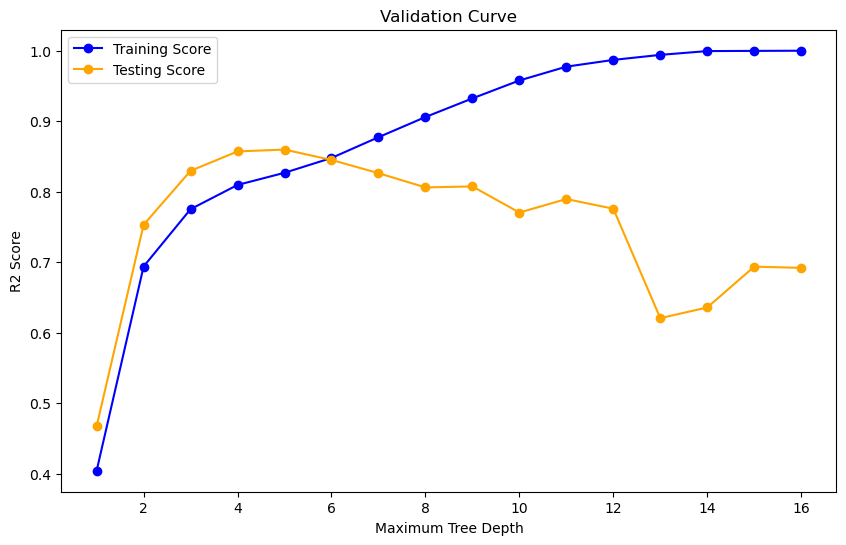

In [302]:
max_depths = range(1, 17)
train_scores = []
test_scores = []

for depth in max_depths :
    model = DecisionTreeRegressor(max_depth = depth, random_state = 42)

    model.fit(X_train,y_train)

    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))

    train_scores.append(train_r2)
    test_scores.append(test_r2)
plt.figure(figsize=(10, 6))

plt.plot(max_depths, train_scores, label='Training Score', marker='o', color='blue')
plt.plot(max_depths, test_scores, label='Testing Score', marker='o', color='orange')

plt.xlabel('Maximum Tree Depth')
plt.ylabel('R2 Score')
plt.title('Validation Curve')
plt.legend()





In [303]:
best_test_score = max(test_scores)
index = test_scores.index(best_test_score)
best_depth = max_depths[index]

print(f"The absolute highest testing score was {best_test_score:.4f}")
print(f"This occurred at exactly max_depth = {best_depth}\n")
final_tree_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)

final_tree_model.fit(X_train, y_train)
final_tree_pred = final_tree_model.predict(X_test)
final_tree_r2 = r2_score(y_test,final_tree_pred)

print("the final r2 score for our new model is ", final_tree_r2)

The absolute highest testing score was 0.8596
This occurred at exactly max_depth = 5

the final r2 score for our new model is  0.8596082827090022


### Final Decision tree after tuning

**The Results:**
* **Unconstrained Tree (Depth 19):** Test $R^2$ = 0.62 (Severe Overfitting)
* **Tuned Tree (Depth 5):** Test $R^2$ = 0.84 

**Conclusion:**
By restricting the tree to a maximum depth of 5, we prevented the algorithm from memorizing individual patient records. Instead, it was forced to learn only the most important, generalizable rules (like Smoking Status and Age brackets). This simple hyperparameter tuning resulted in a massive +22% jump in real-world accuracy, allowing this non-linear model to officially outperform our Baseline Linear Regression!

### Ensemble Learning (The Random Forest)(Bagging)

**The Objective:**
While our single Tuned Decision Tree performed well, it was highly sensitive to the exact depth we chose. To create a more robust model, we will use a **Random Forest Regressor**. 

**The Mechanics:**
Instead of training one tree, this algorithm uses **Bagging (Bootstrap Aggregating)** to train 100 independent Decision Trees on 100 slightly different, randomized versions of our training data. When predicting a new patient's bill, the model passes the patient through all 100 trees and calculates the mathematical average of their predictions, effectively eliminating the high variance (overfitting) of individual trees.

In [304]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print(f"Training R²: {rf_train_r2:.4f}")
print(f"Testing R²:  {rf_test_r2:.4f}")
print(f"Gap:         {rf_train_r2 - rf_test_r2:.4f}")

Training R²: 0.9677
Testing R²:  0.8272
Gap:         0.1405


###  Sequential Ensemble (Gradient Boosting)

**The Objective:**
While a Random Forest builds 100 independent trees (Bagging), Gradient Boosting builds an assembly line of trees (Boosting). We will use this algorithm to see if we can squeeze out even more accuracy by forcing the model to aggressively hunt down its own mistakes.

**The Mechanics:**
1. The model makes a single baseline prediction for all patients.
2. It calculates the Residual Error (Mistake) for every patient.
3. Tree 1 is built specifically to predict and fix those exact mistakes.
4. Tree 2 is built to fix the leftover mistakes from Tree 1.
This sequential error-correction repeats for 100 trees, resulting in a highly optimized prediction engine.

In [305]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1,random_state=42)
gb_model.fit(X_train , y_train)
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

gb_train_r2 = r2_score(y_train,gb_train_pred)
gb_test_r2 = r2_score(y_test,gb_test_pred)

print(f"Training R²: {gb_train_r2:.4f}")
print(f"Testing R²:  {gb_test_r2:.4f}")
print(f"Gap:         {gb_train_r2 - gb_test_r2:.4f}")

Training R²: 0.8614
Testing R²:  0.8683
Gap:         -0.0069


### Gradient Boosting with Early Stopping

**The Objective:**
Gradient Boosting is highly prone to overfitting if we add too many trees (`n_estimators`). Instead of manually guessing the perfect number of trees, we will use a technique called **Early Stopping**.

**The Mechanics:**
We will tell the model to build up to 1,000 trees. However, we will hold back a small "Validation Set" (20% of the training data). After every new tree is built, the model will test itself on this validation set. If the error fails to improve for 10 consecutive trees, the algorithm will automatically halt training and lock in the optimal number of trees.

In [306]:
gb_tuned_model = GradientBoostingRegressor(n_estimators = 1000, learning_rate = 0.05, random_state = 42, validation_fraction = 0.2,n_iter_no_change=10)
gb_tuned_model.fit(X_train, y_train)
optimal_trees = gb_tuned_model.n_estimators_
optimal_trees

#here optimal trees is equal to 100, so we wont need to tune the model differently

100

### Final Model Comparison & Selection

**The Objective:**
To make a decision on which algorithm to deploy to production, we must consolidate the performance metrics (R², MAE, and RMSE) of all our trained models into a single comparative table. 

**Selection Criteria:**
We are looking for the model that maximizes the Testing R² while minimizing the MAE/RMSE, with the smallest possible gap between Training and Testing scores.

In [307]:
def get_metrics(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    return {
        "Train R²": round(train_r2, 4),
        "Test R²": round(test_r2, 4),
        "R² Gap": round(train_r2 - test_r2, 4),
        "Train MAE": round(train_mae, 4),
        "Test MAE": round(test_mae, 4),
        "Train RMSE": round(train_rmse, 4),
        "Test RMSE": round(test_rmse, 4)
    }

leaderboard = {
    "Linear Regression": get_metrics(lr_model, X_train, y_train, X_test, y_test),
    "Decision Tree (Tuned)": get_metrics(final_tree_model, X_train, y_train, X_test, y_test),
    "Random Forest": get_metrics(rf_model, X_train, y_train, X_test, y_test),
    "Gradient Boosting (Tuned)": get_metrics(gb_tuned_model, X_train, y_train, X_test, y_test)
}

leaderboard_df = pd.DataFrame(leaderboard).T

leaderboard_df = leaderboard_df.sort_values(by="Test R²", ascending=False)

leaderboard_df

,Train R²,Test R²,R² Gap,Train MAE,Test MAE,Train RMSE,Test RMSE
Gradient Boosting (Tuned),0.8384,0.8686,-0.0302,0.1863,0.1811,0.3527,0.3321
Decision Tree (Tuned),0.8267,0.8596,-0.0329,0.1944,0.1847,0.3653,0.3433
Random Forest,0.9677,0.8272,0.1405,0.0810,0.1927,0.1576,0.3808
Linear Regression,0.7351,0.8046,-0.0695,0.2845,0.2720,0.4517,0.4050


###  Feature Importance (Model Interpretability)

**The Objective:**
Tree-based ensemble models  calculate "Feature Importance" based on how much each feature contributes to reducing the overall Mean Squared Error across all trees. We will extract these values and plot them to provide actionable business insights into what drives medical costs.

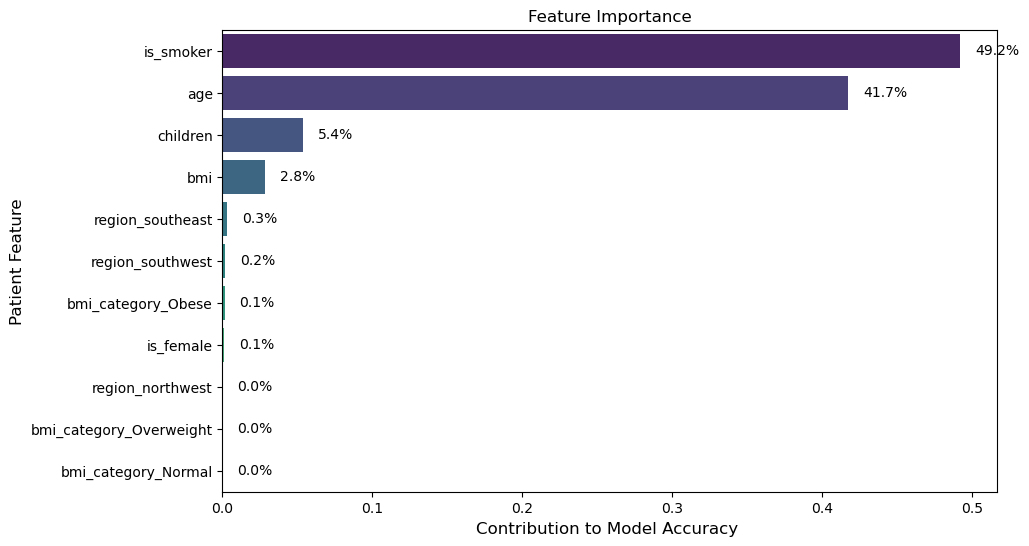

In [308]:
features = X_train.columns
important_features = gb_tuned_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': important_features
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Feature Importance')
plt.xlabel('Contribution to Model Accuracy ', fontsize=12)
plt.ylabel('Patient Feature', fontsize=12)

for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.01, index, f"{value*100:.1f}%", va='center', fontsize=10)


